In [3]:
from __future__ import annotations
from typing import Iterable, Callable

import random
import numpy as np
import pandas as pd
from math import log
import networkx as nx
from scipy.stats import pearsonr
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet
from freyrelab.nets import models, dissimilarity

from netective.utils import get_clusters
from netective.structure.structure import association, compare_structure, create_symmetric_heatmap


In [ ]:
"C:\Users\jmere\Dropbox (FreyreLab)\Libraries\freyrelab\src\freyrelab\__init__.pyc"

In [13]:
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids)                      # get the regnets {regnet_id: RegNet}


seed = 42
random.seed(seed)
random_graph = {}
hm_seed_size = 3

for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.scale_free_graph(n, seed=seed)
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=False)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)

networks = {**regnets, **random_graph}
# convert to directed (force)
networks = {name: nx.DiGraph(G) for name, G in networks.items()}
networks_nodata = {}
for name, G in networks.items():
    H = nx.DiGraph()
    H.add_nodes_from(G.nodes()) # to keep isolated nodes
    H.add_edges_from([(n1, n2) for n1, n2, d in G.edges(data=True)])
    networks_nodata[name] = H

In [2]:
import inspect
from netective.structure import properties
parent_class = properties._Property

undirected_scalar_properties = []
directed_scalar_properties = []
for name, obj in inspect.getmembers(properties):
        if inspect.isclass(obj) and issubclass(obj, parent_class) and obj != parent_class:
            if obj._return_type == 'scalar':
                if obj._use_direction:
                    directed_scalar_properties.append(obj.CLASS_NAME)
                else:
                    undirected_scalar_properties.append(obj.CLASS_NAME)

directed_scalar_properties, undirected_scalar_properties

(['Complex Feed-Forward Circuits',
  'Density',
  'Entropy of Out-Degree Distribution',
  'Feed-Forward Circuits',
  '3-Feedback Loops',
  'Gini Index',
  'Max In-Dregree',
  'Max Out-Degree',
  'Number of Arcs',
  'Regulators',
  'Self Regulations'],
 ['Average Local Efficiency',
  'Average Shortest Path Length',
  'Center',
  'Diameter',
  'Entropy of Degree Distribution',
  'Gene % in the Giant Component',
  'Global Efficiency',
  'Max Degree',
  'Number of Edges',
  'Number of Nodes',
  'Periphery',
  'Radius',
  'Self-Loops',
  'Undirected Density',
  'Undirected Gini Index'])

In [15]:
from itertools import combinations

property_sets = {}
property_sets[tuple(directed_scalar_properties)] = tuple(directed_scalar_properties) # no undirected properties

for i in range(len(directed_scalar_properties)+1):
    possible_comb_directed = list(combinations(directed_scalar_properties, i))
    
    for comb in possible_comb_directed:
        name = ['Undirected'] + list(comb)
        comb = list(undirected_scalar_properties) + list(comb)
        # name = ['Undirected'] + list(comb) # This caused a bug in the code, comb already had the undirected props
        property_sets[tuple(name)] = tuple(comb)

In [16]:
len(networks_nodata)

210

In [17]:
my_props = directed_scalar_properties + undirected_scalar_properties
scalar, dists = compare_structure(networks=networks_nodata, norm='network', return_prop_dicts=True, workers=10, selected_props = my_props)

Properties used for analysis: 
Average Local Efficiency
Average Shortest Path Length
Center
Complex Feed-Forward Circuits
Density
Diameter
Entropy of Degree Distribution
Entropy of Out-Degree Distribution
Feed-Forward Circuits
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
Max Degree
Max In-Dregree
Max Out-Degree
Number of Arcs
Number of Edges
Number of Nodes
Periphery
Radius
Regulators
Self-Loops
Self Regulations
Undirected Density
Undirected Gini Index


210it [00:26,  7.92it/s]                                                                                               


In [18]:
models_ = {
        'BA' : 0,
        'SF' : 1,
        'ER' : 2,
        'HM' : 3,
        }

rand_scores = {}
for name, my_props in property_sets.items():
# for name, my_props in list(property_sets.items())[:3]:

    sub_scalar = {
    name_net: {name_prop: value for name_prop, value in prop_value.items() if name_prop in my_props}
    for name_net, prop_value in scalar.items()
    }

    df = association(sub_scalar, corr_func=pearsonr)
    gs = [models_.get(name.split('_')[0], 4) for name in df.index] # 4 for biological
    clusters = get_clusters(df, 5, map_ids=False) # 5 clusters
    rand_scores[name] = adjusted_rand_score(gs, clusters)


In [19]:
# save the whole dict as a file
import pickle
with open('rand_scores_isolates.pkl', 'wb') as f:
    pickle.dump(rand_scores, f)

# From here to load dataset

In [3]:
import inspect
from netective.structure import properties
parent_class = properties._Property

undirected_scalar_properties = []
directed_scalar_properties = []
for name, obj in inspect.getmembers(properties):
        if inspect.isclass(obj) and issubclass(obj, parent_class) and obj != parent_class:
            if obj._return_type == 'scalar':
                if obj._use_direction:
                    directed_scalar_properties.append(obj.CLASS_NAME)
                else:
                    undirected_scalar_properties.append(obj.CLASS_NAME)

In [99]:
# load the whole dict as a file
import pickle
with open('rand_scores_isolates.pkl', 'rb') as f:
    rand_scores = pickle.load(f)

rand_scores = {tuple(set(k) - set(undirected_scalar_properties)) : v for k, v in rand_scores.items()}
minprops_score = sorted(rand_scores.items(), key=lambda x: (-x[1], len(x[0])))
[x for x in minprops_score if 'Regulators' not in x[0]][:3], minprops_score[:10]

([(('Max In-Dregree',
    'Max Out-Degree',
    'Gini Index',
    'Undirected',
    'Entropy of Out-Degree Distribution'),
   1.0),
  (('Max In-Dregree',
    'Complex Feed-Forward Circuits',
    'Max Out-Degree',
    'Self Regulations',
    'Gini Index',
    'Undirected'),
   1.0),
  (('Max In-Dregree',
    'Self Regulations',
    'Max Out-Degree',
    'Gini Index',
    'Density',
    'Undirected'),
   1.0)],
 [(('Undirected', 'Regulators'), 1.0),
  (('Undirected', 'Complex Feed-Forward Circuits', 'Regulators'), 1.0),
  (('Undirected', 'Density', 'Regulators'), 1.0),
  (('Undirected', 'Entropy of Out-Degree Distribution', 'Regulators'), 1.0),
  (('Undirected', 'Feed-Forward Circuits', 'Regulators'), 1.0),
  (('3-Feedback Loops', 'Undirected', 'Regulators'), 1.0),
  (('Max In-Dregree', 'Undirected', 'Regulators'), 1.0),
  (('Undirected', 'Number of Arcs', 'Regulators'), 1.0),
  (('Undirected', 'Self Regulations', 'Regulators'), 1.0),
  (('Undirected', 'Complex Feed-Forward Circuits', 'D

In [100]:
import pandas as pd
from itertools import chain

data = minprops_score


In [108]:
# Create a list of unique index strings
unique_indices = list(set(chain.from_iterable([props for props, score in data]))) + ['Rand score']

# Create an empty DataFrame with the unique index strings as columns
df = pd.DataFrame(index=unique_indices)

for i, (props, rand) in enumerate(data):
    df[i] = [1 if index in props else 0 for index in unique_indices]
    df.loc['Rand score', i] = rand

df_norand = df.drop('Rand score', axis=0)


C:\Users\jmere\AppData\Local\Temp\ipykernel_36340\2444656800.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i] = [1 if index in props else 0 for index in unique_indices]
C:\Users\jmere\AppData\Local\Temp\ipykernel_36340\2444656800.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[i] = [1 if index in props else 0 for index in unique_indices]
C:\Users\jmere\AppData\Local\Temp\ipykernel_36340\2444656800.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

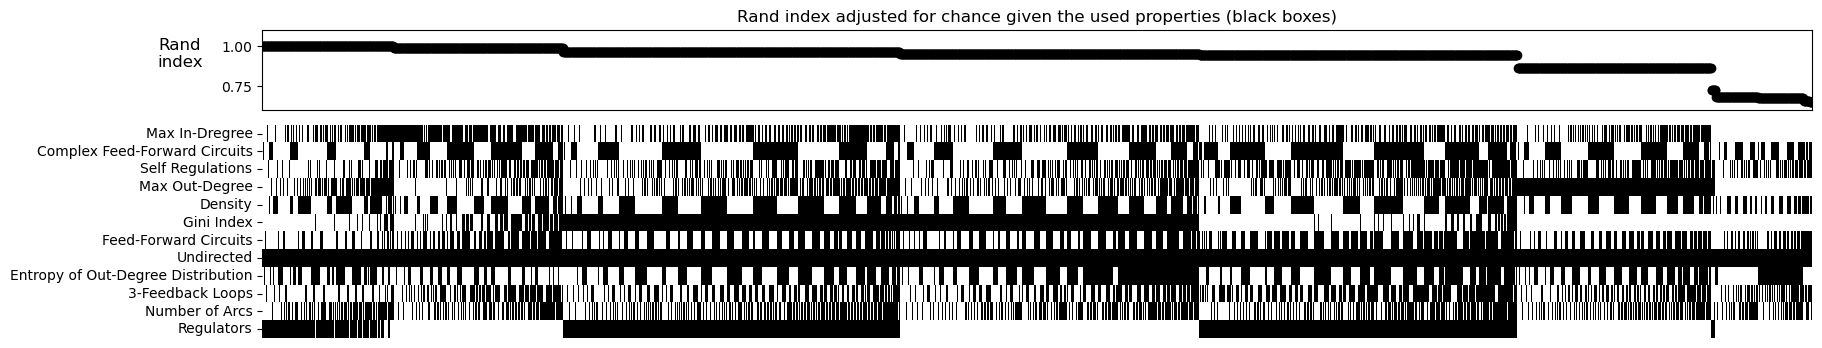

In [112]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = df.reindex(sorted(df.index), axis=0)

# Create a figure with a shared x-axis
fig = plt.figure(figsize=(20, 4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 8], hspace=0.1)  # Swapped height_ratios

# Plot the rand-index values in the first row
ax2 = fig.add_subplot(gs[0])
ax2.plot(df.loc['Rand score'].to_numpy(), color='k', marker='o',linewidth=0)
ax2.set_title('Rand index adjusted for chance given the used properties (black boxes)')
ax2.set_ylabel('Rand\nindex', rotation=0, labelpad=30, size=12)
ax2.set_ylim(0.6, 1.1)
ax2.margins(x=0)
ax2.set_xticks([])

# Plot the heatmap in the second row
ax1 = fig.add_subplot(gs[1])
sns.heatmap(df_norand, cmap='binary', ax=ax1, cbar=False)
# ax1.set_ylabel('Properties')
ax1.set_xticks([])


plt.show()






In [126]:
from collections import defaultdict

weighted_rands = defaultdict(float)
for props, rand in data:
    for prop in props:
        weighted_rands[prop] += rand/len(props)

sorted(weighted_rands.items(), key=lambda x: -x[1])[:10]

[('Undirected', 314.93811519277665),
 ('Regulators', 149.2403861868715),
 ('Gini Index', 149.2341364274132),
 ('Max In-Dregree', 148.0869199914804),
 ('Max Out-Degree', 144.52975336269978),
 ('Density', 143.53598847291516),
 ('Number of Arcs', 143.4955294195867),
 ('Entropy of Out-Degree Distribution', 143.3519331935613),
 ('Complex Feed-Forward Circuits', 143.22516188611687),
 ('Feed-Forward Circuits', 143.22516188611687)]

In [127]:
data[:12]

[(('Undirected', 'Regulators'), 1.0),
 (('Undirected', 'Complex Feed-Forward Circuits', 'Regulators'), 1.0),
 (('Undirected', 'Density', 'Regulators'), 1.0),
 (('Undirected', 'Entropy of Out-Degree Distribution', 'Regulators'), 1.0),
 (('Undirected', 'Feed-Forward Circuits', 'Regulators'), 1.0),
 (('3-Feedback Loops', 'Undirected', 'Regulators'), 1.0),
 (('Max In-Dregree', 'Undirected', 'Regulators'), 1.0),
 (('Undirected', 'Number of Arcs', 'Regulators'), 1.0),
 (('Undirected', 'Self Regulations', 'Regulators'), 1.0),
 (('Undirected', 'Complex Feed-Forward Circuits', 'Density', 'Regulators'),
  1.0),
 (('Undirected',
   'Complex Feed-Forward Circuits',
   'Entropy of Out-Degree Distribution',
   'Regulators'),
  1.0),
 (('Max In-Dregree',
   'Complex Feed-Forward Circuits',
   'Undirected',
   'Regulators'),
  1.0)]